# 사이킷런으로 훈련 세트와 테스트 세트 나누기

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn import datasets  # 데이타셋을 불러온다
import matplotlib.pyplot as plt
import numpy as np

## 예제 데이터 불러오기

In [8]:
diabate = datasets.load_diabetes() # 당뇨 예제를 불러온다. (데이터 정규화된 파일이다)
print(diabate) # 확인해 본다. target부분이 정답이다.

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10)), 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [9]:
print(diabate['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

### 당뇨병 데이터셋
총 442명의 당뇨병 환자에 대해 연령, 성별, 체질량지수, 평균 혈압, 그리고 6가지 혈청 측정값을 포함한 10개의 기준 변수와 기준 시점으로부터 1년 후의 질병 진행 정도를 정량적으로 측정한 관심 변수가 수집되었습니다.

데이터 세트 특징
- 인스턴스 수: 442
- 속성 수: 처음 10개 열은 수치형 예측값
- 목표: 11번째 열은 기준 시점으로부터 1년 후의 질병 진행 정도를 나타내는 정량적 지표

속성 정보:
- age (나이, 년)
- sex (성별)
- bmi (체질량지수)
- bp (평균 혈압)
- s1 tc (총 혈청 콜레스테롤)
- s2 ldle (저밀도 지단백)
- s3 hdl (고밀도 지단백)
- s4 tch (총 콜레스테롤/HDL 비율)
- s5 ltg (혈청 트리글리세리드 수치의 로그값, 로그값 포함 가능)
- s6 glu (혈당 수치)

참고: 이 10개의 특징 변수는 각각 평균 ​​중심화되었고, 표준 편차에 `n_samples`의 제곱근을 곱한 값으로 스케일링되었습니다 (즉, 각 열의 제곱합이 1이 됩니다).

출처 URL: https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html
더 자세한 내용은 다음을 참조하십시오. : Bradley Efron, Trevor Hastie, Iain Johnstone 및 Robert Tibshirani (2004) "최소각 회귀 분석(Least Angle Regression)", 통계학 연보(Annals of Statistics, 토론 포함), 407-499. (https://web.stanford.edu/~hastie/Papers/LARS/LeastAngle_2002.pdf)

In [13]:
X = diabate['data']
y = diabate['target']
print(X.shape) # 442 * 10개 있다는 뜻
print(y.shape) # 442개 있다는 뜻

(442, 10)
(442,)


In [15]:
bmi = X[:, 2] # 속성에서 2번째 값 (BMI)
# print(bmi) # 데이타가 2차원이 아니고 1차원으로 나온다. (2차원으로 만들어야 한다)

X_new = X[:, np.newaxis, 2] # 축을 하나 강제로 만들어서 2차원 배열로 만든다.
print(X_new)

[[ 0.06169621]
 [-0.05147406]
 [ 0.04445121]
 [-0.01159501]
 [-0.03638469]
 [-0.04069594]
 [-0.04716281]
 [-0.00189471]
 [ 0.06169621]
 [ 0.03906215]
 [-0.08380842]
 [ 0.01750591]
 [-0.02884001]
 [-0.00189471]
 [-0.02560657]
 [-0.01806189]
 [ 0.04229559]
 [ 0.01211685]
 [-0.0105172 ]
 [-0.01806189]
 [-0.05686312]
 [-0.02237314]
 [-0.00405033]
 [ 0.06061839]
 [ 0.03582872]
 [-0.01267283]
 [-0.07734155]
 [ 0.05954058]
 [-0.02129532]
 [-0.00620595]
 [ 0.04445121]
 [-0.06548562]
 [ 0.12528712]
 [-0.05039625]
 [-0.06332999]
 [-0.03099563]
 [ 0.02289497]
 [ 0.01103904]
 [ 0.07139652]
 [ 0.01427248]
 [-0.00836158]
 [-0.06764124]
 [-0.0105172 ]
 [-0.02345095]
 [ 0.06816308]
 [-0.03530688]
 [-0.01159501]
 [-0.0730303 ]
 [-0.04177375]
 [ 0.01427248]
 [-0.00728377]
 [ 0.0164281 ]
 [-0.00943939]
 [-0.01590626]
 [ 0.0250506 ]
 [-0.04931844]
 [ 0.04121778]
 [-0.06332999]
 [-0.06440781]
 [-0.02560657]
 [-0.00405033]
 [ 0.00457217]
 [-0.00728377]
 [-0.0374625 ]
 [-0.02560657]
 [-0.02452876]
 [-0.01806

## 데이터 분리하기

In [37]:
from sklearn.model_selection import train_test_split #학습 데이터와 테스트 데이터를 분리하기 위해 불러온다.

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.1, random_state=0) # train_size는 0.9가 된다., random_state는 임의의 난수를 넣는다.
print(X_train.shape)
print(y_train.shape)

(397, 1)
(397,)


In [39]:
print(X_test)
print()
print(y_test)

[[ 0.10480869]
 [ 0.06061839]
 [ 0.00888341]
 [-0.02345095]
 [ 0.04552903]
 [ 0.097264  ]
 [-0.02884001]
 [ 0.02289497]
 [ 0.05415152]
 [ 0.04660684]
 [-0.05794093]
 [ 0.04660684]
 [-0.0374625 ]
 [-0.046085  ]
 [ 0.08864151]
 [-0.02237314]
 [-0.05901875]
 [-0.05147406]
 [-0.08380842]
 [ 0.04013997]
 [ 0.02828403]
 [ 0.01103904]
 [-0.02452876]
 [ 0.05846277]
 [ 0.05522933]
 [ 0.01750591]
 [-0.04177375]
 [-0.04500719]
 [ 0.00457217]
 [ 0.02612841]
 [-0.00297252]
 [-0.05255187]
 [-0.0105172 ]
 [-0.01159501]
 [-0.00620595]
 [ 0.02073935]
 [-0.01590626]
 [-0.00943939]
 [ 0.00133873]
 [ 0.03367309]
 [-0.06548562]
 [-0.0105172 ]
 [-0.00728377]
 [-0.00405033]
 [ 0.03043966]]

[321. 215. 127.  64. 175. 275. 179. 232. 142.  99. 252. 174. 129.  74.
 264.  49.  86.  75. 101. 155. 170. 276. 110. 136.  68. 128. 103.  93.
 191. 196. 217. 181. 168. 200. 219. 281. 151. 257.  49. 198.  96. 179.
  95. 198. 244.]


## 훈련시키기

In [40]:
regression = LinearRegression()

In [41]:
regression.fit(X_train, y_train)
regression.coef_
regression.intercept_
y_predict = regression.predict(X_test) # 머신러닝으로 예상하는 값
print(y_predict) # 정답 값 

[252.53071348 209.81076549 159.79716784 128.53866931 195.22346617
 245.23706382 123.32891955 173.3425172  203.55906578 196.26541612
  95.19627087 196.26541612 114.99331994 106.65772033 236.90146421
 129.58061926  94.15432092 101.44797058  70.18947205 190.01371642
 178.55226696 161.88106774 127.49671935 207.72686559 204.60101573
 168.13276745 110.82552014 107.69967029 155.62936803 176.46836705
 148.33571838 100.40602063 141.04206872 140.00011877 145.20986852
 171.2586173  135.83231896 142.08401867 152.50351818 183.76201671
  87.90262122 141.04206872 144.16791857 147.29376842 180.63616686]


## 그래프 그리기

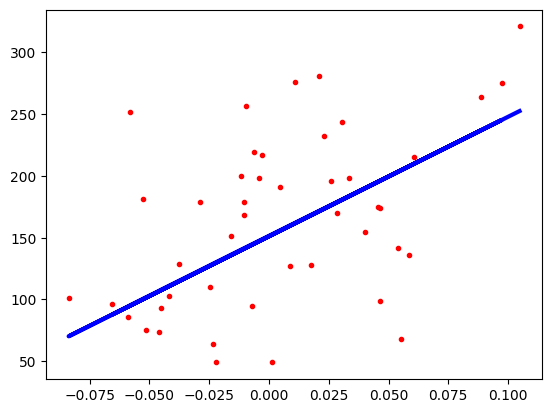

In [ ]:
plt.scatter(X_test, y_test, c='r', marker='.')
plt.plot(X_test, y_predict, color='blue', linewidth=3)
plt.show() # bmi가 높은 사람이 당뇨에 걸릴 확률이 높다

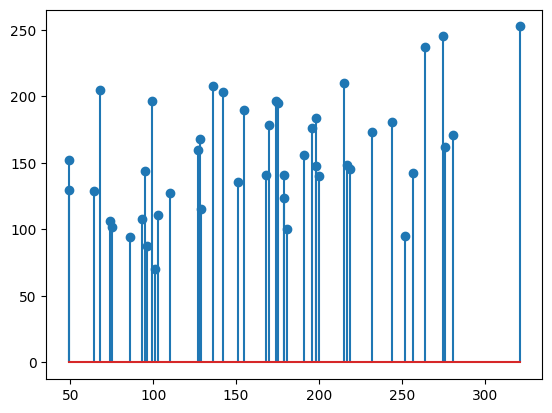

In [ ]:
plt.stem(y_test, y_predict) # 예상값과 정답의 차이를 stem으로 확인
plt.show()